# **Telecom Churn Classification**

Let's build our first classification model using KNN algorithm, with the Telecom churn
dataset.

The goal is to classify the churn. Also verify with what accuracy the KNN Classifier model will classify the churn.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

#import the telecom churn dataset
df_churn = pd.read_csv('/content/drive/MyDrive/Gen AI/churn-bigml-20.csv')
print(df_churn)

    State  Account length  Area code International plan Voice mail plan  \
0      LA             117        408                 No              No   
1      IN              65        415                 No              No   
2      NY             161        415                 No              No   
3      SC             111        415                 No              No   
4      HI              49        510                 No              No   
..    ...             ...        ...                ...             ...   
662    WI             114        415                 No             Yes   
663    AL             106        408                 No             Yes   
664    VT              60        415                 No              No   
665    WV             159        415                 No              No   
666    CT             184        510                Yes              No   

     Number vmail messages  Total day minutes  Total day calls  \
0                        0       

The target, "churn" has values of False and True.

True indicates the customers are likely to churn, and False indicates the customers will not churn.

For our classification model, let's consider the columns **"account_length"** and **"customer_service_calls"** as **features**.

account length indicates customer loyalty, and frequent customer service calls may signal dissatisfaction, both of which can be good predictors of churn.

In [ ]:
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

x = df_churn[["Account length","Customer service calls"]].values
y = df_churn['Churn'].values

# Create a KNN classifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)

# Fit the classifier to the data
knn.fit(x,y)

KNeighborsClassifier(n_neighbors=6)

Now that our KNN classifier has been fit to the data, it can be used to predict the labels of new data points.

All available data has been used for training, however, fortunately, there are new observations available. Let's load them as X_new. Let's use our classifier to predict the labels of a set of new data points (X_new):

In [ ]:
x_new = np.array([[30.0,17.5],[107.0,24.1],[213.0,10.9]])

In [ ]:
#Create y_pred by predicting the target values of the unseen features X_new using the knn model.
y_pred = knn.predict(x_new)

#Print the predicted labels for the set of predictions:
print("Prediction: {}".format(y_pred))

Prediction: [False  True False]


The model has predicted that the first and third customers will not churn in the new array. But how do we know how accurate these predictions are? Let's measure our model's performance using Accuracy metric.

In classification, Accuracy is a commonly-used metric. Accuracy is the number of correct predictions divided by the total number of observations.

**But how do you measure Accuracy?**

Well, you need to split the data into a training set and a test set. We fit the classifier using the training set, we then calculate the model's accuracy against the test set's labels.


In [ ]:
#import the module
from sklearn.model_selection import train_test_split

x = df_churn.drop(["Churn", "State", "International plan", "Voice mail plan"], axis = 1).values
y = df_churn['Churn'].values

In [ ]:
#split into training and test sets
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the classifier to the training data
knn.fit(X_train,y_train)

# Print the accuracy
print(knn.score(x_test,y_test))

0.8955223880597015


After fitting our KNN model, we got the Accuracy of 89.55%, with a K-value of 5

i.e, our classifier model is accurately able to classify the churn with a score of 89.55%

But the question here is, does our model produce the same accuracy with the changing values of 'K', or does it increase or decrease? Let's find out.

**Note:** We can interpret 'k' using a model complexity curve. With a KNN model, we can calculate accuracy on the training and test sets using incremental k values, and plot the results.

### **Model Complexity:**

Interpreting model complexity is a great way to evaluate supervised learning
performance. Let's produce a model that can interpret the relationship between features and the target variable, as well as generalize well when exposed to new observations.


In [ ]:
#Create the neighbors as a numpy array of k-values from 1 up to and including 12:
neighbors = np.arange(1,13)
train_accuracies = {}
test_accuracies = {}

#we use a for loop to repeat our previous workflow, building several models using a different no of neighbors:
for neighbor in neighbors:
  #set up a knn classifier
  knn = KNeighborsClassifier(n_neighbors=neighbor)

  #fit the model
  knn.fit(x_train,y_train)

  #compute accuracy scores for the training set and test set separtely:
  train_accuracies[neighbor] = knn.score(x_train,y_train)
  test_accuracies[neighbor] = knn.score(x_test,y_test)

print(neighbors,'\n', train_accuracies, '\n', test_accuracies)

[ 1  2  3  4  5  6  7  8  9 10 11 12] 
 {np.int64(1): 1.0, np.int64(2): 0.9118198874296435, np.int64(3): 0.9136960600375235, np.int64(4): 0.8874296435272045, np.int64(5): 0.8949343339587242, np.int64(6): 0.8761726078799249, np.int64(7): 0.8855534709193246, np.int64(8): 0.8761726078799249, np.int64(9): 0.8818011257035647, np.int64(10): 0.8761726078799249, np.int64(11): 0.8799249530956847, np.int64(12): 0.8799249530956847} 
 {np.int64(1): 0.8134328358208955, np.int64(2): 0.8731343283582089, np.int64(3): 0.8731343283582089, np.int64(4): 0.8805970149253731, np.int64(5): 0.8955223880597015, np.int64(6): 0.8955223880597015, np.int64(7): 0.8731343283582089, np.int64(8): 0.8880597014925373, np.int64(9): 0.8955223880597015, np.int64(10): 0.8955223880597015, np.int64(11): 0.9029850746268657, np.int64(12): 0.8880597014925373}


Notice how training accuracy decreases as the number of neighbors initially gets larger,and vice versa for the testing accuracy? These scores would be much easier to interpret in a line plot, so let's produce a model complexity curve of these results.

## **Visualizing model complexity:**

Let's create a model complexity curve to visualize how performance changes as the model becomes less complex!

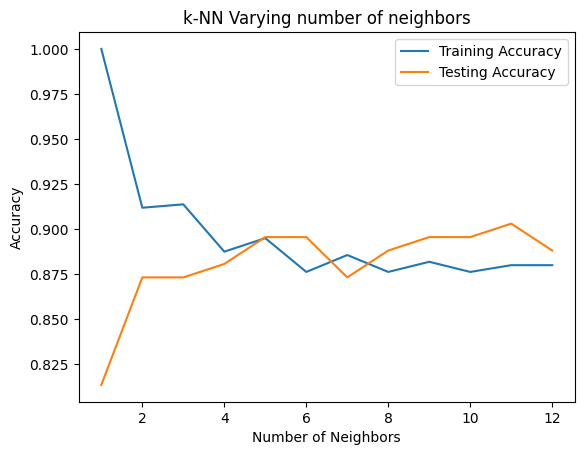

In [ ]:
import matplotlib.pyplot as plt
#add a title
plt.title('k-NN Varying number of neighbors')

#plot training accuracies:
plt.plot(neighbors, train_accuracies.values(), label = 'Training Accuracy')

#plot test accuracies:
plt.plot(neighbors, test_accuracies.values(), label = 'Testing Accuracy')

plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
#Display the plot
plt.show()

# **Inference:**

From the above plot, we see that the training accuracy decreases and test accuracy increases as the number of neighbors (K-values) gets larger. For the test set, the accuracy peaks with 8 neighbors, suggesting it is the optimal value for our model. Also, with a K-value of 8 the accuracy is increased (88.80%) compared to a K-value of 4.
